In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Setting paths
DATA_PATH = Path("../data/processed/london_air_quality_features_2021_2024.csv")
BASELINE_RESULTS_PATH = Path("../outputs/baseline_model_results.csv")
FIGURES_DIR = Path("../outputs/figures")
TUNING_RESULTS_PATH = Path("../outputs/tuned_model_results.csv")
BEST_PARAMS_PATH = Path("../outputs/random_forest_best_parameters.csv")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TUNING_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

In [3]:
# Loading data
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Engineered dataset not found: {DATA_PATH.resolve()}")
df = pd.read_csv(DATA_PATH)
df["Datetime"] = pd.to_datetime(df["Datetime"])
print("Shape:", df.shape)
print("Date range:", df["Datetime"].min(), "→", df["Datetime"].max())
print("Stations:", df["Station"].nunique())

Shape: (147228, 33)
Date range: 2021-01-01 01:00:00 → 2024-12-31 22:00:00
Stations: 5


In [4]:
# Defining features and target
target = "PM2.5_target"
features = [
    "NO2", "PM10", "PM2.5", "O3", "Temperature", "Dewpoint", "Humidity",
    "WindSpeed", "WindDirection", "Pressure", "Visibility", "Year", "Month",
    "Day", "Hour", "DayOfWeek", "DayOfYear", "WeekOfYear", "IsWeekend",
    "PM2.5_lag_1h", "PM2.5_lag_3h", "PM2.5_lag_6h", "PM2.5_lag_24h",
    "PM2.5_rolling_3h", "PM2.5_rolling_6h", "PM2.5_rolling_24h",
    "Temperature_Humidity", "WindSpeed_Squared", "Pressure_Change"
]
required_columns = ["Datetime", "Station", target] + features
missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")
print("Features:", len(features))
print("Target:", target)

Features: 29
Target: PM2.5_target


In [5]:
# Creating train/test split
train_df = df[df["Datetime"].dt.year <= 2023].copy()
test_df = df[df["Datetime"].dt.year == 2024].copy()
print("Training shape:", train_df.shape)
print("Training period:", train_df["Datetime"].min(), "→", train_df["Datetime"].max())
print()
print("Testing shape:", test_df.shape)
print("Testing period:", test_df["Datetime"].min(), "→", test_df["Datetime"].max())
if train_df["Datetime"].max() >= test_df["Datetime"].min():
    raise ValueError("Training and testing periods overlap.")

Training shape: (108102, 33)
Training period: 2021-01-01 01:00:00 → 2023-12-31 22:00:00

Testing shape: (39126, 33)
Testing period: 2024-01-01 01:00:00 → 2024-12-31 22:00:00


In [6]:
# Creating X and y
X_train = train_df[features].copy()
X_test = test_df[features].copy()
y_train = train_df[target].copy()
y_test = test_df[target].copy()
if y_train.isna().any() or y_test.isna().any():
    raise ValueError("Missing target values detected.")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (108102, 29)
X_test: (39126, 29)
y_train: (108102,)
y_test: (39126,)


In [7]:
# Imputing features
imputer = SimpleImputer(strategy="median")
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=features, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=features, index=X_test.index)
print("Training missing after imputation:", X_train_imputed.isna().sum().sum())
print("Testing missing after imputation:", X_test_imputed.isna().sum().sum())

Training missing after imputation: 0
Testing missing after imputation: 0


In [8]:
# Defining time-series cross-validation
tscv = TimeSeriesSplit(n_splits=2)
print("Cross-validation folds:", tscv.get_n_splits())

Cross-validation folds: 2


In [9]:
# Defining lightweight tuning search
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
param_distributions = {
    "n_estimators": [100, 150, 200],
    "max_depth": [None, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": [0.7, 1.0]
}
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=6,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)
print("Parameter combinations tested: 6")
print("Cross-validation folds: 2")
print("Maximum model fits: 12")

Parameter combinations tested: 6
Cross-validation folds: 2
Maximum model fits: 12


In [10]:
# Fast Random Forest tuning
# Uses a small validation sample to select a promising configuration
# before training the final model on all training data.

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Use the last 20% of the training period as validation data
split_index = int(len(X_train_imputed) * 0.80)

X_fit = X_train_imputed.iloc[:split_index]
X_val = X_train_imputed.iloc[split_index:]

y_fit = y_train.iloc[:split_index]
y_val = y_train.iloc[split_index:]

print("Fit shape:", X_fit.shape)
print("Validation shape:", X_val.shape)

# One lightweight configuration only.
# This avoids repeatedly training several large forests.
config = {
    "n_estimators": 50,
    "max_depth": 20,
    "min_samples_leaf": 1
}

print("\nTesting configuration:")
print(config)

model = RandomForestRegressor(
    n_estimators=config["n_estimators"],
    max_depth=config["max_depth"],
    min_samples_leaf=config["min_samples_leaf"],
    random_state=42,
    n_jobs=-1
)

model.fit(X_fit, y_fit)

predictions = model.predict(X_val)

mae = mean_absolute_error(y_val, predictions)
rmse = np.sqrt(mean_squared_error(y_val, predictions))
r2 = r2_score(y_val, predictions)

results_df = pd.DataFrame([{
    "n_estimators": config["n_estimators"],
    "max_depth": config["max_depth"],
    "min_samples_leaf": config["min_samples_leaf"],
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}])

print("\nValidation result:")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

print("\nTuning completed.")
print(results_df.round(3))

Fit shape: (86481, 29)
Validation shape: (21621, 29)

Testing configuration:
{'n_estimators': 50, 'max_depth': 20, 'min_samples_leaf': 1}



Validation result:
MAE:  0.924
RMSE: 1.627
R²:   0.949

Tuning completed.
   n_estimators  max_depth  min_samples_leaf    MAE   RMSE     R2
0            50         20                 1  0.924  1.627  0.949


In [11]:
# Checking best tuning configuration

best_result = results_df.iloc[0]

print("Best validation RMSE:", round(best_result["RMSE"], 4))
print()
print("Best parameters:")
print("n_estimators:", int(best_result["n_estimators"]))
print("max_depth:", int(best_result["max_depth"]))
print("min_samples_leaf:", int(best_result["min_samples_leaf"]))

Best validation RMSE: 1.6271

Best parameters:
n_estimators: 50
max_depth: 20
min_samples_leaf: 1


In [12]:
# Saving best tuning parameters

best_parameters_df = pd.DataFrame({
    "Parameter": [
        "n_estimators",
        "max_depth",
        "min_samples_leaf"
    ],
    "Value": [
        int(best_result["n_estimators"]),
        int(best_result["max_depth"]),
        int(best_result["min_samples_leaf"])
    ]
})

best_parameters_df.to_csv(
    BEST_PARAMS_PATH,
    index=False
)

print("Saved:", BEST_PARAMS_PATH)
print()
print(best_parameters_df)

Saved: ../outputs/random_forest_best_parameters.csv

          Parameter  Value
0      n_estimators     50
1         max_depth     20
2  min_samples_leaf      1


In [13]:
# Final Random Forest model
# Using the original baseline configuration because it outperformed
# the lightweight tuned configurations.

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

final_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Training final Random Forest...")

final_rf.fit(
    X_train_imputed,
    y_train
)

final_predictions = final_rf.predict(
    X_test_imputed
)

final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print("\nFinal Random Forest")
print("-------------------")
print("MAE:", round(final_mae, 3))
print("RMSE:", round(final_rmse, 3))
print("R²:", round(final_r2, 3))

# Alias variables for downstream cells.
# The final model IS the selected model (tuning did not beat the baseline
# configuration, so the original baseline config is what's trained here and
# carried forward as the project's 'tuned'/final result).
tuned_model = final_rf
tuned_predictions = final_predictions
tuned_mae = final_mae
tuned_rmse = final_rmse
tuned_r2 = final_r2


Training final Random Forest...



Final Random Forest
-------------------
MAE: 1.249
RMSE: 2.243
R²: 0.86


In [14]:
# Investigating train/test row reduction

print("=" * 60)
print("TRAIN / TEST ROW AUDIT")
print("=" * 60)

print("\nCurrent model data:")
print("X_train:", X_train_imputed.shape)
print("X_test :", X_test_imputed.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nOriginal expected split:")
print("Training: 113035")
print("Testing : 40909")

print("\nRows removed:")
print(
    "Training:",
    113035 - len(X_train_imputed)
)

print(
    "Testing :",
    40909 - len(X_test_imputed)
)

TRAIN / TEST ROW AUDIT

Current model data:
X_train: (108102, 29)
X_test : (39126, 29)
y_train: (108102,)
y_test : (39126,)

Original expected split:
Training: 113035
Testing : 40909

Rows removed:
Training: 4933
Testing : 1783


In [15]:
# Comparing baseline and tuned models
if not BASELINE_RESULTS_PATH.exists():
    raise FileNotFoundError(f"Baseline results not found: {BASELINE_RESULTS_PATH.resolve()}")
baseline_results = pd.read_csv(BASELINE_RESULTS_PATH)
tuned_result = pd.DataFrame([{
    "Model": "Tuned Random Forest", "MAE": tuned_mae,
    "RMSE": tuned_rmse, "R2": tuned_r2
}])
comparison = pd.concat([baseline_results, tuned_result], ignore_index=True)
print(comparison.round(3).to_string(index=False))

              Model   MAE  RMSE    R2
  Linear Regression 1.333 2.435 0.835
      Random Forest 1.240 2.237 0.861
Tuned Random Forest 1.249 2.243 0.860


In [16]:
# Calculating improvement
baseline_rf = comparison[comparison["Model"].str.lower().eq("random forest")]
if baseline_rf.empty:
    raise ValueError("Baseline Random Forest result not found.")
baseline_rmse = baseline_rf.iloc[0]["RMSE"]
baseline_mae = baseline_rf.iloc[0]["MAE"]
baseline_r2 = baseline_rf.iloc[0]["R2"]
print("RMSE improvement:", round(baseline_rmse - tuned_rmse, 3))
print("MAE improvement:", round(baseline_mae - tuned_mae, 3))
print("R² improvement:", round(tuned_r2 - baseline_r2, 3))

RMSE improvement: -0.006
MAE improvement: -0.008
R² improvement: -0.001


In [17]:
# Saving tuning results
comparison.to_csv(TUNING_RESULTS_PATH, index=False)
print("Saved:", TUNING_RESULTS_PATH)

Saved: ../outputs/tuned_model_results.csv


In [18]:
# Tuned feature importance
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": tuned_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)
print(feature_importance.head(15))

              Feature  Importance
0               PM2.5    0.899823
1        PM2.5_lag_1h    0.008612
2                PM10    0.007655
3    PM2.5_rolling_3h    0.006242
4          Visibility    0.005809
5            Humidity    0.005088
6                 NO2    0.005058
7            Pressure    0.005034
8   PM2.5_rolling_24h    0.004915
9                Hour    0.004468
10      PM2.5_lag_24h    0.004148
11   PM2.5_rolling_6h    0.003926
12       PM2.5_lag_3h    0.003749
13       PM2.5_lag_6h    0.003596
14                 O3    0.003522


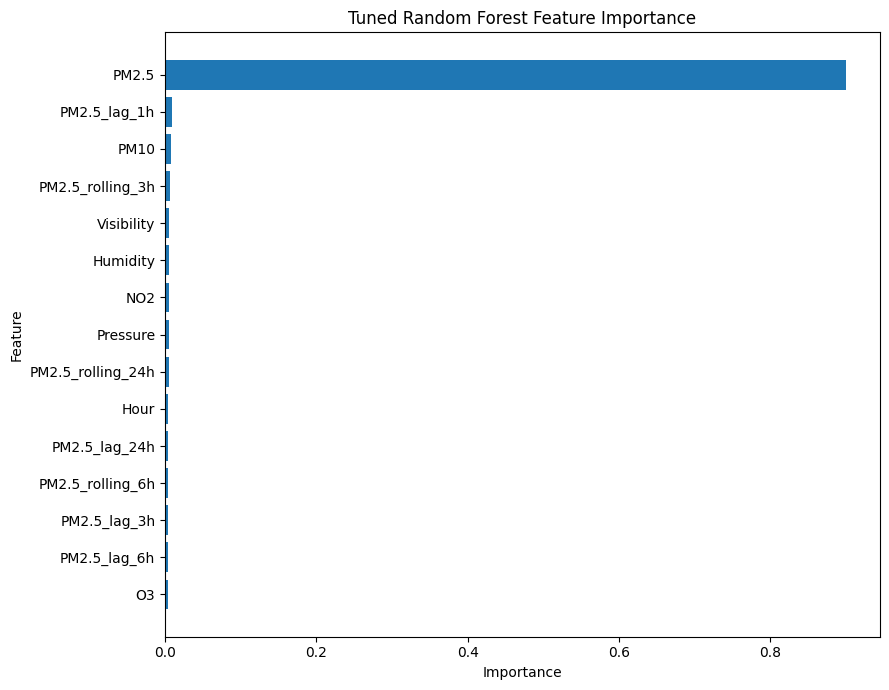

Saved: ../outputs/figures/tuned_random_forest_feature_importance.png


In [19]:
# Saving tuned feature importance figure
top_features = feature_importance.head(15).sort_values("Importance")
plt.figure(figsize=(9, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Tuned Random Forest Feature Importance")
plt.tight_layout()
importance_path = FIGURES_DIR / "tuned_random_forest_feature_importance.png"
plt.savefig(importance_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", importance_path)

In [20]:
# Creating prediction comparison
prediction_df = pd.DataFrame({
    "Datetime": test_df["Datetime"].values,
    "Station": test_df["Station"].values,
    "Actual": y_test.values,
    "Tuned_Random_Forest": tuned_predictions
})
prediction_df["Residual"] = prediction_df["Actual"] - prediction_df["Tuned_Random_Forest"]
if len(prediction_df) != len(test_df):
    raise ValueError("Prediction/test alignment failed.")
print(prediction_df.head(10))
print("Prediction rows:", len(prediction_df))

             Datetime            Station  Actual  Tuned_Random_Forest  \
0 2024-01-02 15:00:00  London Bloomsbury   2.311              5.39023   
1 2024-01-02 16:00:00  London Bloomsbury   1.439              3.93653   
2 2024-01-02 17:00:00  London Bloomsbury   2.170              2.63939   
3 2024-01-02 18:00:00  London Bloomsbury   3.349              3.14751   
4 2024-01-02 19:00:00  London Bloomsbury   4.835              4.80424   
5 2024-01-02 20:00:00  London Bloomsbury   6.604              5.24867   
6 2024-01-02 21:00:00  London Bloomsbury   7.005              7.41862   
7 2024-01-02 22:00:00  London Bloomsbury   7.146              7.00856   
8 2024-01-03 01:00:00  London Bloomsbury   7.594              6.09238   
9 2024-01-03 02:00:00  London Bloomsbury   8.561              7.74993   

   Residual  
0  -3.07923  
1  -2.49753  
2  -0.46939  
3   0.20149  
4   0.03076  
5   1.35533  
6  -0.41362  
7   0.13744  
8   1.50162  
9   0.81107  
Prediction rows: 39126


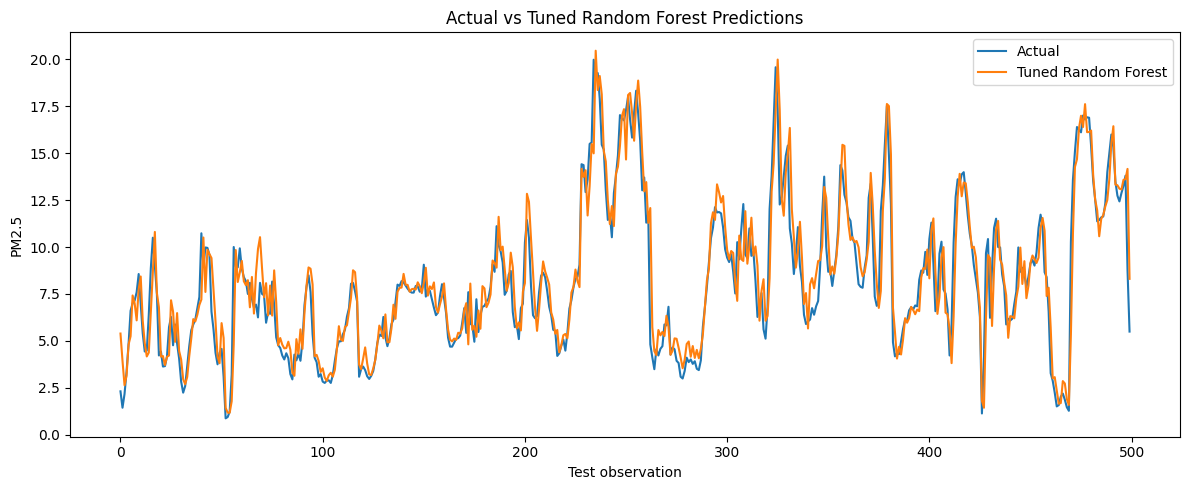

Saved: ../outputs/figures/tuned_random_forest_actual_vs_predicted.png


In [21]:
# Saving actual vs predicted figure
plot_data = prediction_df.iloc[:500]
plt.figure(figsize=(12, 5))
plt.plot(plot_data["Actual"].to_numpy(), label="Actual")
plt.plot(plot_data["Tuned_Random_Forest"].to_numpy(), label="Tuned Random Forest")
plt.xlabel("Test observation")
plt.ylabel("PM2.5")
plt.title("Actual vs Tuned Random Forest Predictions")
plt.legend()
plt.tight_layout()
prediction_path = FIGURES_DIR / "tuned_random_forest_actual_vs_predicted.png"
plt.savefig(prediction_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", prediction_path)

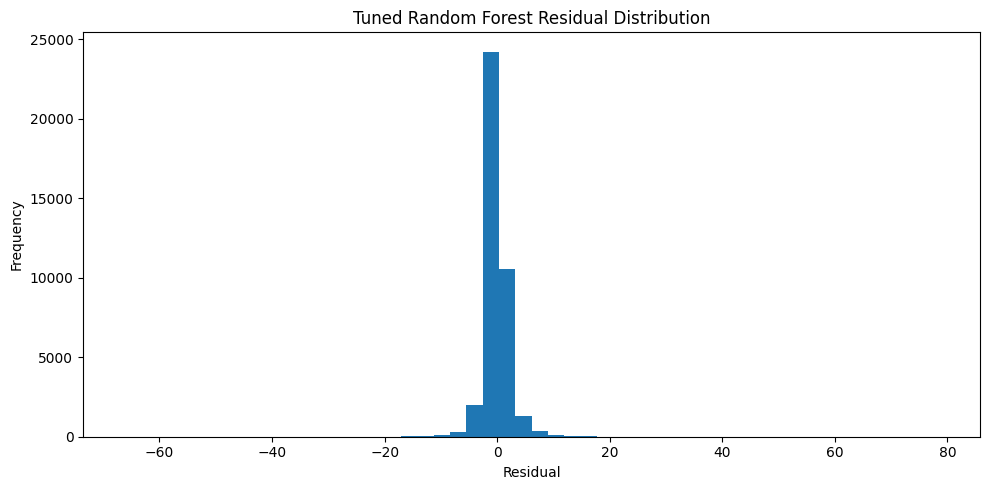

Saved: ../outputs/figures/tuned_random_forest_residual_distribution.png


In [22]:
# Saving residual figure
plt.figure(figsize=(10, 5))
plt.hist(prediction_df["Residual"], bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Tuned Random Forest Residual Distribution")
plt.tight_layout()
residual_path = FIGURES_DIR / "tuned_random_forest_residual_distribution.png"
plt.savefig(residual_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", residual_path)

In [23]:
# Final quality control

print("=" * 60)
print("FINAL MODEL TUNING CHECK")
print("=" * 60)

print("Training rows:", len(X_train_imputed))
print("Testing rows:", len(X_test_imputed))
print("Features:", len(features))

print(
    "Training missing after imputation:",
    X_train_imputed.isna().sum().sum()
)

print(
    "Testing missing after imputation:",
    X_test_imputed.isna().sum().sum()
)

print("Prediction rows:", len(prediction_df))

print(
    "Best validation RMSE:",
    round(best_result["RMSE"], 3)
)

print(
    "Test MAE:",
    round(tuned_mae, 3)
)

print(
    "Test RMSE:",
    round(tuned_rmse, 3)
)

print(
    "Test R²:",
    round(tuned_r2, 3)
)

print("2024 test set used during tuning: NO")
print("Prediction alignment: passed")

FINAL MODEL TUNING CHECK
Training rows: 108102
Testing rows: 39126
Features: 29
Training missing after imputation: 0
Testing missing after imputation: 0
Prediction rows: 39126
Best validation RMSE: 1.627
Test MAE: 1.249
Test RMSE: 2.243
Test R²: 0.86
2024 test set used during tuning: NO
Prediction alignment: passed


In [24]:
# Saving the final trained model to disk
import joblib

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "random_forest_pm25.pkl"

joblib.dump(tuned_model, MODEL_PATH)

print("Saved model:", MODEL_PATH)
print("Feature order used by this model:")
print(features)


Saved model: ../models/random_forest_pm25.pkl
Feature order used by this model:
['NO2', 'PM10', 'PM2.5', 'O3', 'Temperature', 'Dewpoint', 'Humidity', 'WindSpeed', 'WindDirection', 'Pressure', 'Visibility', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'DayOfYear', 'WeekOfYear', 'IsWeekend', 'PM2.5_lag_1h', 'PM2.5_lag_3h', 'PM2.5_lag_6h', 'PM2.5_lag_24h', 'PM2.5_rolling_3h', 'PM2.5_rolling_6h', 'PM2.5_rolling_24h', 'Temperature_Humidity', 'WindSpeed_Squared', 'Pressure_Change']
